# 03b Image Dataset Inspection

## Goal
This notebook inspects the downloaded image dataset created in `03_image_scraping.ipynb`.

The notebook will:
- load the scraping metadata
- summarise image counts by literary unit
- preview downloaded images
- check for missing or corrupted files
- record basic image properties such as width and height

This step helps assess dataset quality before later stages such as image captioning, emotion analysis, and generation.

## Step 1 — Import libraries
Import the libraries needed for metadata loading, file inspection, and image visualisation.

In [2]:
from pathlib import Path
import json
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

## Step 2 — Load the project config
Load the project paths created earlier.

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent
CONFIG_PATH = PROJECT_ROOT / "src" / "project_config.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

RAW_IMAGES_DIR = Path(config["raw_images_dir"])
OUTPUT_TABLES_DIR = Path(config["output_tables_dir"])

print("Raw images dir:", RAW_IMAGES_DIR)
print("Output tables dir:", OUTPUT_TABLES_DIR)

Raw images dir: D:\Work\Workspace\Projects\Python\data-driven-surface\data\raw\scraped_images
Output tables dir: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\tables


## Step 3 — Load scraping metadata
Read the metadata CSV generated in Notebook 03.

In [4]:
metadata_csv_path = OUTPUT_TABLES_DIR / "image_scraping_metadata.csv"

if not metadata_csv_path.exists():
    raise FileNotFoundError(
        f"Metadata CSV not found: {metadata_csv_path}\n"
        "Please run 03_image_scraping.ipynb first."
    )

metadata_df = pd.read_csv(metadata_csv_path)
metadata_df.head()

,unit_id,city_group,search_query,image_rank,image_url,source_url,title,local_path,download_success,error
0,1,Cities & Memory 1,"surreal city architecture, silver, domes, bron...",1,https://pics.craiyon.com/2023-10-24/332aa5adef...,https://www.craiyon.com/image/BtAnG3xCRzWOAD7q...,Cityscape with silver domes and bronze statues...,D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN
1,1,Cities & Memory 1,"surreal city architecture, silver, domes, bron...",2,https://pics.craiyon.com/2024-04-28/oTRPsNoNT5...,https://www.craiyon.com/image/Vmzk7YtkTdWm6uDu...,"City with silver domes, bronze statues, paved ...",D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN
2,1,Cities & Memory 1,"surreal city architecture, silver, domes, bron...",3,https://pics.craiyon.com/2023-10-07/d79e0b758b...,https://www.craiyon.com/search/aerial+view+of+...,aerial view of a city with silver domes and br...,D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN
3,2,Cities & Memory 2,"surreal city architecture, spiral, buildings, ...",1,https://images.stockcake.com/public/8/e/d/8ed0...,https://stockcake.com/i/spiral-urban-dreamscap...,"Free Spiral Urban Dreamscape Image - Spiral, S...",D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN
4,2,Cities & Memory 2,"surreal city architecture, spiral, buildings, ...",2,https://cdn.openart.ai/published/uNXcBp8dNKILa...,https://openart.ai/search/architecture,OpenArt - Find and Easily Create Customized ar...,D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN


## Step 4 — Summarise image counts by unit
Check how many images were downloaded for each literary unit.

In [5]:
summary_df = (
    metadata_df.groupby(["unit_id", "city_group"])["download_success"]
    .agg(
        total_images="count",
        successful_images="sum"
    )
    .reset_index()
)

summary_df["failed_images"] = summary_df["total_images"] - summary_df["successful_images"]
summary_df.head(10)

,unit_id,city_group,total_images,successful_images,failed_images
0,1,Cities & Memory 1,3,3,0
1,2,Cities & Memory 2,3,3,0
2,3,Cities & Desire 1,3,3,0
3,4,Cities & Memory 3,3,3,0
4,5,Cities & Desire 2,3,3,0
5,6,Cities & Signs 1,3,3,0
6,7,Cities & Memory 4,3,3,0
7,8,Cities & Desire 3,3,3,0
8,9,Cities & Signs 2,3,3,0
9,10,Thin Cities 1,3,3,0


## Step 5 — Visualise successful image counts
Plot the number of successfully downloaded images for each unit.

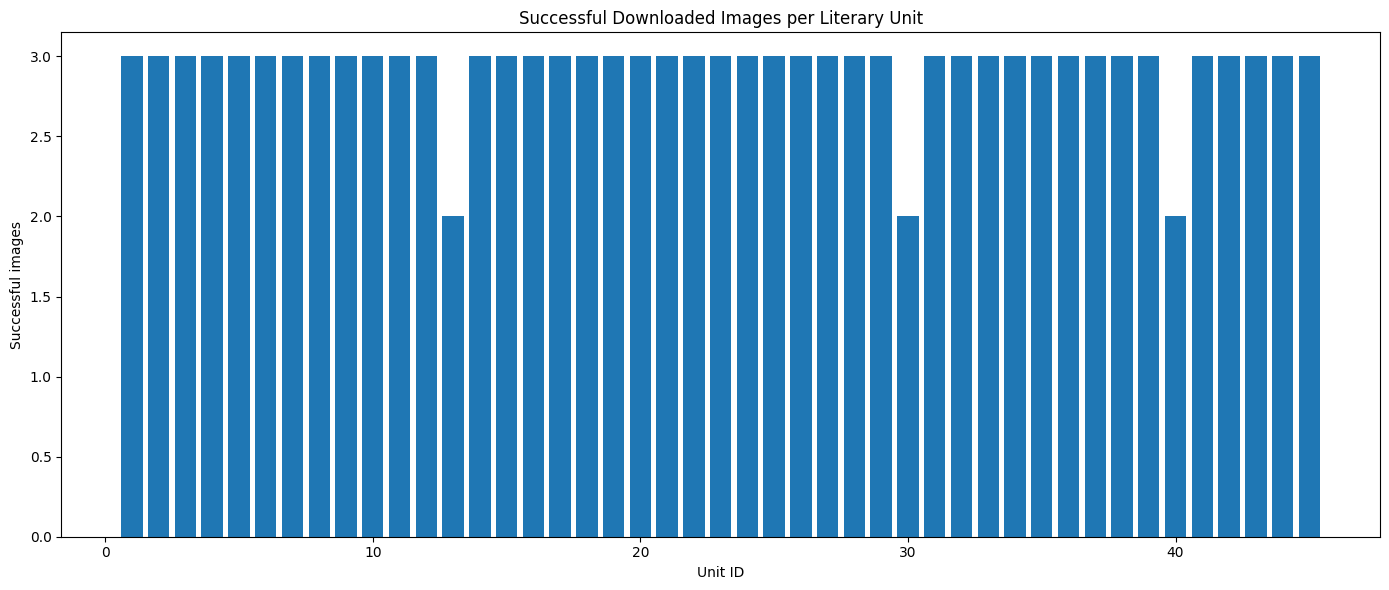

In [6]:
plt.figure(figsize=(14, 6))
plt.bar(summary_df["unit_id"], summary_df["successful_images"])
plt.xlabel("Unit ID")
plt.ylabel("Successful images")
plt.title("Successful Downloaded Images per Literary Unit")
plt.tight_layout()
plt.show()

## Step 6 — Check for missing local files
Confirm that all successful records point to files that actually exist.

In [7]:
metadata_df["file_exists"] = metadata_df["local_path"].apply(lambda p: Path(p).exists())

missing_files_df = metadata_df[(metadata_df["download_success"] == True) & (metadata_df["file_exists"] == False)]
missing_files_df.head()

,unit_id,city_group,search_query,image_rank,image_url,source_url,title,local_path,download_success,error,file_exists


## Step 7 — Inspect image dimensions and validity
Open each successfully downloaded image and record:
- width
- height
- whether it can be opened safely

In [8]:
inspection_records = []

success_df = metadata_df[metadata_df["download_success"] == True].copy()

for row in success_df.itertuples(index=False):
    img_path = Path(row.local_path)

    width, height = None, None
    valid_image = False
    error = None

    try:
        with Image.open(img_path) as img:
            width, height = img.size
            valid_image = True
    except Exception as e:
        error = str(e)

    inspection_records.append({
        "unit_id": row.unit_id,
        "city_group": row.city_group,
        "image_rank": row.image_rank,
        "local_path": str(img_path),
        "width": width,
        "height": height,
        "valid_image": valid_image,
        "error": error
    })

inspection_df = pd.DataFrame(inspection_records)
inspection_df.head()

,unit_id,city_group,image_rank,local_path,width,height,valid_image,error
0,1,Cities & Memory 1,1,D:\Work\Workspace\Projects\Python\data-driven-...,1024,1024,True,None
1,1,Cities & Memory 1,2,D:\Work\Workspace\Projects\Python\data-driven-...,1024,1024,True,None
2,1,Cities & Memory 1,3,D:\Work\Workspace\Projects\Python\data-driven-...,1024,1024,True,None
3,2,Cities & Memory 2,1,D:\Work\Workspace\Projects\Python\data-driven-...,384,672,True,None
4,2,Cities & Memory 2,2,D:\Work\Workspace\Projects\Python\data-driven-...,512,819,True,None


## Step 8 — Summarise image validity
Check how many images are valid and whether any files are corrupted.

In [9]:
print("Total inspected images:", len(inspection_df))
print("Valid images:", inspection_df["valid_image"].sum())
print("Invalid images:", (~inspection_df["valid_image"]).sum())

Total inspected images: 132
Valid images: 132
Invalid images: 0


## Step 9 — Identify unusual image sizes
This helps detect very small, low-quality, or suspicious images.

In [10]:
small_images_df = inspection_df[
    (inspection_df["valid_image"] == True) &
    ((inspection_df["width"] < 300) | (inspection_df["height"] < 300))
]

small_images_df.head(20)

,unit_id,city_group,image_rank,local_path,width,height,valid_image,error


## Step 10 — Preview sample images for selected units
Display a few downloaded images to assess their relevance and visual quality.

In [11]:
def show_unit_images(unit_id, max_images=3):
    rows = metadata_df[
        (metadata_df["unit_id"] == unit_id) &
        (metadata_df["download_success"] == True)
    ].head(max_images)

    if rows.empty:
        print(f"No successful images found for unit {unit_id}.")
        return

    fig, axes = plt.subplots(1, len(rows), figsize=(5 * len(rows), 5))
    if len(rows) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, rows.iterrows()):
        img_path = Path(row["local_path"])
        try:
            with Image.open(img_path) as img:
                ax.imshow(img)
                ax.set_title(f"Unit {row['unit_id']}\n{row['city_group']}\nRank {row['image_rank']}")
                ax.axis("off")
        except Exception as e:
            ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

## Step 11 — Show sample images
Preview a few literary units and inspect the visual relevance of the results.

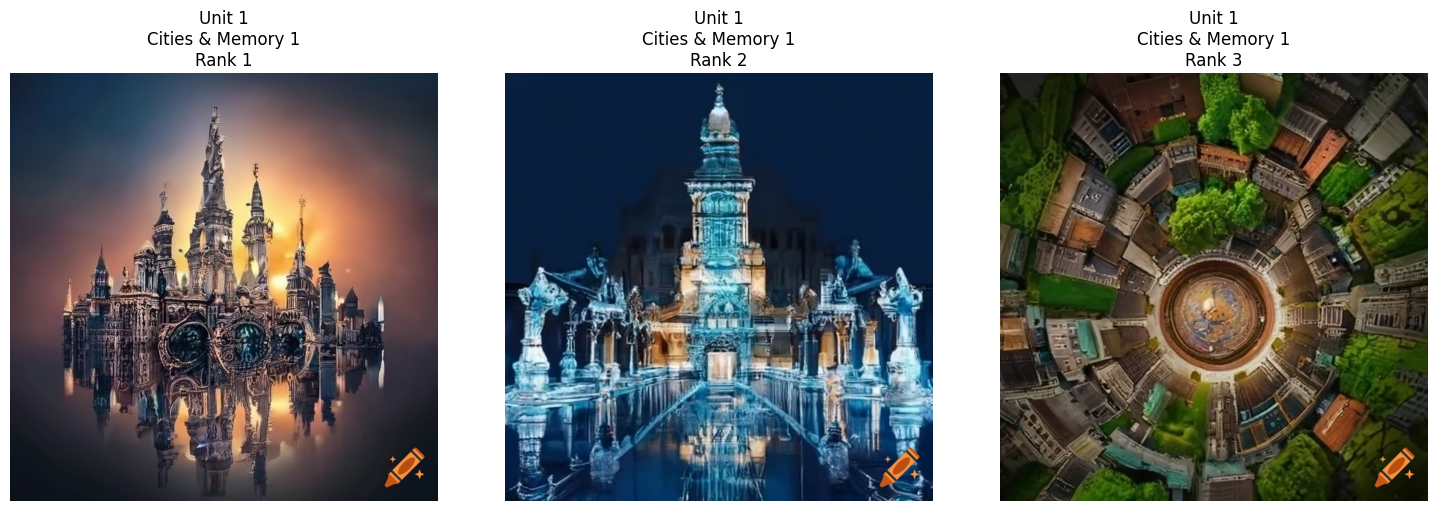

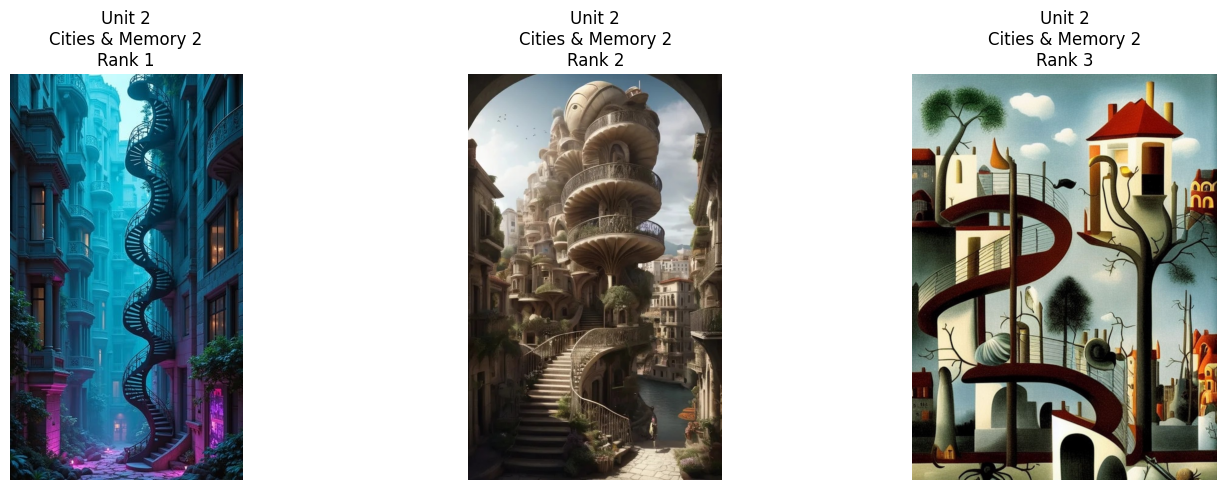

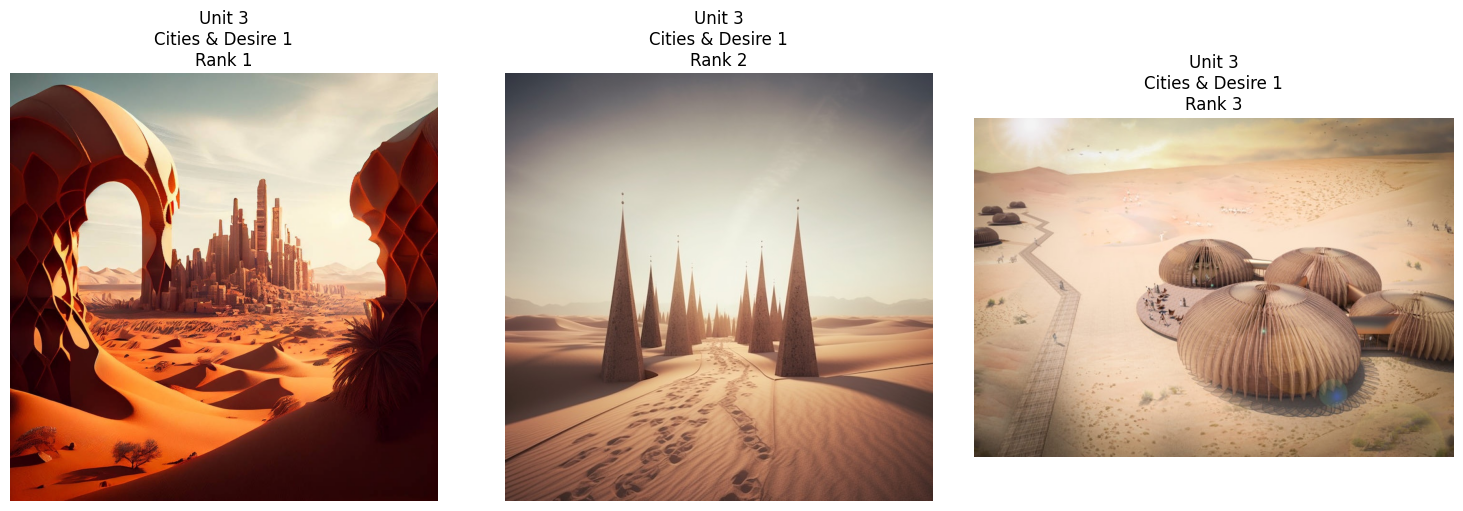

In [12]:
show_unit_images(1, max_images=3)
show_unit_images(2, max_images=3)
show_unit_images(3, max_images=3)

## Step 12 — Merge metadata with inspection results
Combine download metadata and image inspection data into one table.

In [13]:
merged_df = metadata_df.merge(
    inspection_df,
    on=["unit_id", "city_group", "image_rank", "local_path"],
    how="left"
)

merged_df.head()

,unit_id,city_group,search_query,image_rank,image_url,source_url,title,local_path,download_success,error_x,file_exists,width,height,valid_image,error_y
0,1,Cities & Memory 1,"surreal city architecture, silver, domes, bron...",1,https://pics.craiyon.com/2023-10-24/332aa5adef...,https://www.craiyon.com/image/BtAnG3xCRzWOAD7q...,Cityscape with silver domes and bronze statues...,D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN,True,1024.0,1024.0,True,None
1,1,Cities & Memory 1,"surreal city architecture, silver, domes, bron...",2,https://pics.craiyon.com/2024-04-28/oTRPsNoNT5...,https://www.craiyon.com/image/Vmzk7YtkTdWm6uDu...,"City with silver domes, bronze statues, paved ...",D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN,True,1024.0,1024.0,True,None
2,1,Cities & Memory 1,"surreal city architecture, silver, domes, bron...",3,https://pics.craiyon.com/2023-10-07/d79e0b758b...,https://www.craiyon.com/search/aerial+view+of+...,aerial view of a city with silver domes and br...,D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN,True,1024.0,1024.0,True,None
3,2,Cities & Memory 2,"surreal city architecture, spiral, buildings, ...",1,https://images.stockcake.com/public/8/e/d/8ed0...,https://stockcake.com/i/spiral-urban-dreamscap...,"Free Spiral Urban Dreamscape Image - Spiral, S...",D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN,True,384.0,672.0,True,None
4,2,Cities & Memory 2,"surreal city architecture, spiral, buildings, ...",2,https://cdn.openart.ai/published/uNXcBp8dNKILa...,https://openart.ai/search/architecture,OpenArt - Find and Easily Create Customized ar...,D:\Work\Workspace\Projects\Python\data-driven-...,True,NaN,True,512.0,819.0,True,None


## Step 13 — Save the inspection table
Export the image inspection results for later filtering and analysis.

In [14]:
inspection_csv_path = OUTPUT_TABLES_DIR / "image_dataset_inspection.csv"
merged_df.to_csv(inspection_csv_path, index=False, encoding="utf-8-sig")

print("Saved inspection data to:", inspection_csv_path)

Saved inspection data to: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\tables\image_dataset_inspection.csv


## Step 14 — Summary
This notebook has:
- loaded the scraping metadata
- summarised image counts by literary unit
- checked file existence
- recorded image dimensions and validity
- previewed sample images
- exported an inspection table for later use

Next notebook:
- `04_ai_text_generation.ipynb` or image-derived analysis